# STT Benchmark - Whisper (tiny / base / small) sobre audios de Gaudi

Pipeline per comparar variants de Whisper (`faster-whisper`) en velocitat (temps d'inferencia) i precisio (WER) sobre un conjunt d'audios curts sobre Antoni Gaudi.
Genera un `predictions.json` estructurat.

## 1. Setup i muntatge de Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q faster-whisper jiwer pandas matplotlib seaborn

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.5/39.5 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 101.5 MB/s eta 0:00:00


In [2]:
import os
import re
import time
import json

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import jiwer
from faster_whisper import WhisperModel
import torch

sns.set_theme(style="whitegrid")
print("Llibreries carregades. GPU disponible:", torch.cuda.is_available())

Llibreries carregades. GPU disponible: True


## 2. Configuracio: carpeta d'audios i ground truth

- `AUDIO_DIR`: carpeta a Drive on tens els fitxers (`G1`, `G2`, `G_cb`, `G_pg`, etc.).
- `GROUND_TRUTH`: diccionari `nom_fitxer -> text correcte`.
- `INITIAL_PROMPT`: paraules clau de domini que ajuden Whisper a encertar noms propis (Gaudi, Sagrada Familia...).

In [3]:
AUDIO_DIR = "/content/drive/MyDrive/gaudi_dataset/audio"  # AJUSTA la ruta a la teva carpeta


# Tens 18 fitxers en total: 4 en .ogg + 14 en .m4a (G1..G14)
GROUND_TRUTH = {
    # --- format .ogg ---
    "G_cb.ogg":          "Casa Batlló (The Organic Façade). Located on the famous Passeig de Gràcia, Casa Batlló is a masterpiece of architectural storytelling, mythological symbolism, and organic design. The Dragon-Back Roof: The colorful, scaly, arched roofline is specifically designed to look like the back of a sleeping reptile. This directly ties into the local Catalan legend of Saint George (Sant Jordi) slaying the dragon, with the tower and its cross representing the saint's lance piercing the beast's back. The Skull Balconies: The exterior is famous for its cast-iron balconies that closely resemble theatrical masks or human skulls, supported by stone pillars that look like bones. This striking contrast highlights Gaudí's mastery of materials, utilizing the structural integrity of iron castings alongside traditional stone masonry to create a dreamlike, skeletal facade.",
    "g_completito.ogg":  "Gaudí's Visionary Masterpieces in Barcelona. Antoni Gaudí completely transformed the landscape of Barcelona with his unique, organic, and nature-inspired architectural style, leaving a legacy of breathtaking buildings that continue to fascinate visitors from all over the world. His absolute masterpiece, La Sagrada Família, is a towering basilica that has been under construction since 1882. Its Nativity Facade celebrates life with intricate, highly detailed sculptures, contrasting sharply with the angular, minimalist Passion Facade that depicts the death of Christ. Stepping inside the basilica feels like entering a magical forest; Gaudí designed massive pillars that branch out near the ceiling like trees, perfectly distributing the weight of the vault while bathing the interior in colorful light from the magnificent stained glass windows. Beyond the basilica, Gaudí seamlessly integrated human construction into the natural landscape at Park Güell. Originally conceived in 1900 as a luxury housing estate for wealthy families, it was eventually turned into a public park. The space features raw stone viaducts with leaning columns that mimic tree trunks, engineered to withstand the lateral pressure of the earth behind them. It is also home to the iconic multicolored salamander guarding the main staircase, which serves as the perfect showcase of trencadís—a pioneering technique that recycles broken ceramic tiles into vibrant mosaics. Finally, his genius for residential architecture and storytelling is fully displayed at Casa Batlló. Located on the famous Passeig de Gràcia, the building's facade is a brilliant representation of the local Catalan legend of Saint George (Sant Jordi). The colorful, scaly, arched roofline is designed to look like the back of a sleeping dragon. Below it, the exterior is adorned with cast-iron balconies that resemble masks or skulls, and stone pillars that look like bones. This skeletal design showcases Gaudí's brilliant understanding of structural integrity, blending cast iron and stone masonry to create an unforgettable, dreamlike facade. Together, these three monuments define Gaudí's visionary genius and remain the absolute crown jewels of Catalan modernism.",
    "G_pg.ogg":          "Park Güell (Nature and Urbanism). Originally conceived as a luxury housing estate for wealthy families, this project was eventually turned into a public park. It is a brilliant example of how Gaudí seamlessly integrated human construction into the natural landscape. The Salamander: The iconic multicolored lizard guarding the main staircase is the perfect showcase of trencadís, a technique that recycles broken ceramic tiles into vibrant mosaics. Structural Innovations: The park features raw stone viaducts with leaning columns that mimic tree trunks, engineered to withstand the lateral pressure of the earth behind them.",
    "G_sf.ogg":          "La Sagrada Família (The Unfinished Basilica). This towering basilica is Gaudí's absolute masterpiece and the most visited monument in Spain. Although construction began in 1882 and remains unfinished, its scale and ambition are unparalleled. The Facades: The Nativity Facade celebrates life with intricate, highly detailed sculptures, contrasting sharply with the angular, minimalist Passion Facade that depicts the death of Christ. The Interior: Stepping inside feels like entering a magical forest. Gaudí designed the massive pillars to branch out near the ceiling like trees, distributing the weight of the vault perfectly while bathing the interior in colorful light from the stained glass windows.",

    # --- format .m4a (G1 a G14) ---
    "G1.m4a":  "When and where was Antoni Gaudí born, and when did he die?",
    "G2.m4a":  "Who was Eusebi Güell and what did he commission from Gaudí?",
    "G3.m4a":  "What is the funicular model technique Gaudí used, and where did he first use it at full scale?",
    "G4.m4a":  "What is trencadís and where is it prominently used?",
    "G5.m4a":  "What are the three main façades of the Sagrada Família and what does each represent?",
    "G6.m4a":  "How many spires will the finished Sagrada Família have, and what do they represent?",
    "G7.m4a":  "Why has construction of the Sagrada Família taken so long?",
    "G8.m4a":  "What was Park Güell originally intended to be, and why did that plan fail?",
    "G9.m4a":  "What is the Hypostyle Room in Park Güell and what dual purpose does it serve?",
    "G10.m4a": "Why is Casa Batlló nicknamed the 'House of Bones', and what does its roof represent?",
    "G11.m4a": "Why is Casa Milà commonly called 'La Pedrera', and what structural innovation does it use?",
    "G12.m4a": "Which Gaudí works were declared UNESCO World Heritage Sites, and in what years?",
    "G13.m4a": "What style influenced Casa Vicens, Gaudí's first major commission?",
    "G14.m4a": "What is notable about the central hall of Palau Güell?",
}

INITIAL_PROMPT = (
    "Antoni Gaudi, Sagrada Familia, Park Guell, Casa Batllo, Casa Mila, La Pedrera, "
    "Casa Vicens, Palau Guell, Eusebi Guell, Barcelona, Catalonia, trencadis, "
    "Hypostyle Room, UNESCO World Heritage, Passeig de Gracia, funicular model"
)

MODELS = ["tiny.en", "base.en", "small.en"]

print(f"{len(GROUND_TRUTH)} fitxers configurats amb ground truth")
missing = [f for f in GROUND_TRUTH if not os.path.exists(os.path.join(AUDIO_DIR, f))]
if missing:
    print("ATENCIO, no trobats a AUDIO_DIR:", missing)
else:
    print("Tots els fitxers de GROUND_TRUTH existeixen a AUDIO_DIR")

todo_left = [f for f, txt in GROUND_TRUTH.items() if txt.startswith("TODO")]
if todo_left:
    print(f"\nEncara et falta omplir el ground truth de {len(todo_left)} fitxers:", todo_left)

18 fitxers configurats amb ground truth
Tots els fitxers de GROUND_TRUTH existeixen a AUDIO_DIR


## 3. Funcions auxiliars: transcripcio i normalitzacio per WER

El WER es molt sensible a majuscules/minuscules i puntuacio, aixi que normalitzem abans de comparar.

In [5]:
def normalize_text(text: str) -> str:
    """Minuscules i neteja de puntuacio, per fer el WER comparable."""
    text = text.lower().strip()
    text = re.sub(r"[^\w\s']", "", text)
    text = re.sub(r"\s+", " ", text)
    return text


def transcribe_file(model: WhisperModel, audio_path: str, initial_prompt: str = None):
    """Transcriu un fitxer i retorna (text_complet, temps_en_segons)."""
    start = time.time()
    segments, info = model.transcribe(audio_path, initial_prompt=initial_prompt, beam_size=5)
    text = " ".join(segment.text.strip() for segment in segments)  # cal consumir el generador
    elapsed = time.time() - start
    return text.strip(), elapsed


def compute_wer(reference: str, hypothesis: str) -> float:
    ref_norm = normalize_text(reference)
    hyp_norm = normalize_text(hypothesis)
    if len(ref_norm) == 0:
        return float("nan")
    return jiwer.wer(ref_norm, hyp_norm)

## 4. Bucle de benchmarking

Per cada model: es carrega una sola vegada (mes eficient) i despres es transcriuen tots els audios. Es guarda: fitxer, model, ground truth, transcripcio, temps d'inferencia i WER.

In [6]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
COMPUTE_TYPE = "float16" if DEVICE == "cuda" else "int8"

results = []

for model_name in MODELS:
    print(f"\n=== Carregant model: {model_name} ({DEVICE}, {COMPUTE_TYPE}) ===")
    model = WhisperModel(model_name, device=DEVICE, compute_type=COMPUTE_TYPE)

    for filename, ground_truth in GROUND_TRUTH.items():
        audio_path = os.path.join(AUDIO_DIR, filename)
        if not os.path.exists(audio_path):
            print(f"  [SKIP] No trobat: {filename}")
            continue

        transcription, elapsed = transcribe_file(model, audio_path, initial_prompt=INITIAL_PROMPT)
        wer_score = compute_wer(ground_truth, transcription)

        print(f"  {filename:15s} | {elapsed:6.2f}s | WER={wer_score:.3f}")

        results.append({
            "filename": filename,
            "model": model_name,
            "ground_truth": ground_truth,
            "transcription": transcription,
            "inference_time_sec": round(elapsed, 4),
            "wer": round(wer_score, 4),
        })

    del model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

print(f"\nBenchmark complet: {len(results)} transcripcions generades")


=== Carregant model: tiny.en (cuda, float16) ===


  G_cb.ogg        |   2.09s | WER=0.457
  g_completito.ogg |   2.83s | WER=0.142
  G_pg.ogg        |   1.06s | WER=0.239
  G_sf.ogg        |   1.65s | WER=0.069
  G1.m4a          |   0.95s | WER=0.167
  G2.m4a          |   1.68s | WER=0.273
  G3.m4a          |   1.50s | WER=0.056
  G4.m4a          |   1.45s | WER=0.111
  G5.m4a          |   1.50s | WER=0.200
  G6.m4a          |   1.45s | WER=0.071
  G7.m4a          |   0.85s | WER=0.300
  G8.m4a          |   1.36s | WER=0.286
  G9.m4a          |   2.89s | WER=0.200
  G10.m4a         |   1.87s | WER=0.200
  G11.m4a         |   1.57s | WER=0.200
  G12.m4a         |   1.42s | WER=0.154
  G13.m4a         |   1.47s | WER=0.222
  G14.m4a         |   0.84s | WER=0.100

=== Carregant model: base.en (cuda, float16) ===
  G_cb.ogg        |   0.95s | WER=0.173
  g_completito.ogg |   1.97s | WER=0.108
  G_pg.ogg        |   1.02s | WER=0.043
  G_sf.ogg        |   1.03s | WER=0.098
  G1.m4a          |   0.39s | WER=0.083
  G2.m4a          |   0.44s 

## 5. Estructurar resultats: DataFrame i export a JSON

In [7]:
df = pd.DataFrame(results)
df = df[["filename", "model", "ground_truth", "transcription", "inference_time_sec", "wer"]]
df

,filename,model,ground_truth,transcription,inference_time_sec,wer
0,G_cb.ogg,tiny.en,Casa Batlló (The Organic Façade). Located on t...,"Casa Batllo, the organic facade. Located on th...",2.0852,0.4567
1,g_completito.ogg,tiny.en,Gaudí's Visionary Masterpieces in Barcelona. A...,Gaudi's visionary masterpiece is in Barcelona....,2.8317,0.1420
2,G_pg.ogg,tiny.en,Park Güell (Nature and Urbanism). Originally c...,"Park Guell, Nature and Urbanism. Originally co...",1.0554,0.2391
3,G_sf.ogg,tiny.en,La Sagrada Família (The Unfinished Basilica). ...,"Sagrada Familia, the unfinished Basilica. This...",1.6453,0.0686
4,G1.m4a,tiny.en,"When and where was Antoni Gaudí born, and when...",When I'm where was Antoni Gaudi born and when ...,0.9482,0.1667
5,G2.m4a,tiny.en,Who was Eusebi Güell and what did he commissio...,Who was Ausebi Guell and what did he commissio...,1.6820,0.2727
6,G3.m4a,tiny.en,What is the funicular model technique Gaudí us...,What is the funicular model technique Gaudi us...,1.4967,0.0556
7,G4.m4a,tiny.en,What is trencadís and where is it prominently ...,"What is trencadis, and where is it, prominentl...",1.4451,0.1111
8,G5.m4a,tiny.en,What are the three main façades of the Sagrada...,What are the three main facadas of the Sera Fa...,1.5017,0.2000
9,G6.m4a,tiny.en,How many spires will the finished Sagrada Famí...,How many spires will the finished Sagrada Fami...,1.4466,0.0714


In [8]:
OUTPUT_JSON = "/content/predictions.json"

with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print(f"Guardat a {OUTPUT_JSON}")
print(f"{len(results)} registres exportats")

Guardat a /content/predictions.json
54 registres exportats


## 6. Grafiques comparatives

In [9]:
summary = df.groupby("model").agg(
    avg_inference_time=("inference_time_sec", "mean"),
    avg_wer=("wer", "mean"),
).reset_index()

# Ordenem els models per mida (tiny -> base -> small) si tots hi son
order = [m for m in MODELS if m in summary["model"].values]
summary["model"] = pd.Categorical(summary["model"], categories=order, ordered=True)
summary = summary.sort_values("model")
summary

,model,avg_inference_time,avg_wer
2,tiny.en,1.578067,0.191422
0,base.en,0.547806,0.178794
1,small.en,0.706972,0.141450


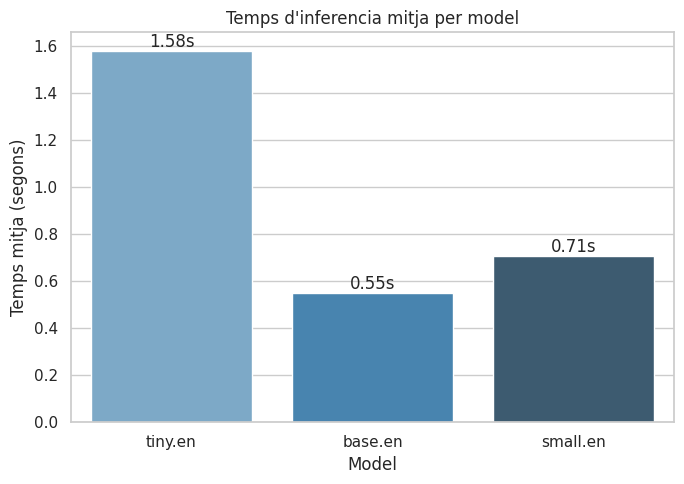

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=summary, x="model", y="avg_inference_time", hue="model", palette="Blues_d", ax=ax, legend=False)
ax.set_title("Temps d'inferencia mitja per model")
ax.set_xlabel("Model")
ax.set_ylabel("Temps mitja (segons)")
for i, v in enumerate(summary["avg_inference_time"]):
    ax.text(i, v, f"{v:.2f}s", ha="center", va="bottom")
plt.tight_layout()
plt.savefig("/content/avg_inference_time.png", dpi=150)
plt.show()

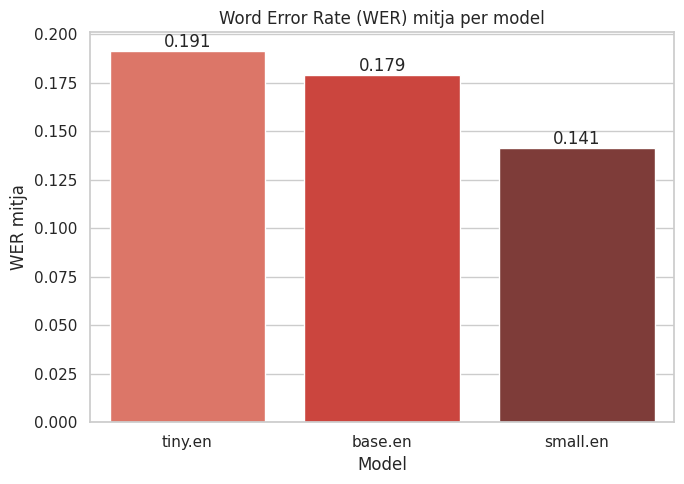

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=summary, x="model", y="avg_wer", hue="model", palette="Reds_d", ax=ax, legend=False)
ax.set_title("Word Error Rate (WER) mitja per model")
ax.set_xlabel("Model")
ax.set_ylabel("WER mitja")
for i, v in enumerate(summary["avg_wer"]):
    ax.text(i, v, f"{v:.3f}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig("/content/avg_wer.png", dpi=150)
plt.show()